In [17]:

import os
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from typing import List, Tuple

# %%
train = pd.read_parquet("../data/model/final_train.parquet")
val   = pd.read_parquet("../data/model/final_val.parquet")
test  = pd.read_parquet("../data/model/final_test.parquet")

print("Train Date range:", train["Date"].min(), "to", train["Date"].max())
print("Val Date range:  ", val["Date"].min(),   "to", val["Date"].max())
print("Test Date range: ", test["Date"].min(),  "to", test["Date"].max())

# Targets as 1D vectors
y_train_vec = train["return_next_day"].values.astype("float32")
y_val_vec   = val["return_next_day"].values.astype("float32")
y_test_vec  = test["return_next_day"].values.astype("float32")

# Keep (Date, tic, y) frames for saving predictions later
y_train = train[["Date", "tic", "return_next_day"]].copy()
y_val   = val[["Date", "tic", "return_next_day"]].copy()
y_test  = test[["Date", "tic", "return_next_day"]].copy()

# Features (drop target)
X_train = train.drop(columns=["return_next_day"]).copy()
X_val   = val.drop(columns=["return_next_day"]).copy()
X_test  = test.drop(columns=["return_next_day"]).copy()

Train Date range: 2016-01-04 00:00:00 to 2021-12-30 00:00:00
Val Date range:   2022-01-03 00:00:00 to 2022-12-30 00:00:00
Test Date range:  2023-01-03 00:00:00 to 2023-12-29 00:00:00


In [18]:
# load prediction
preds_lgbm_best_test_DMS_plus_mean_sent= pd.read_csv("../data/model/preds_lgbm_best_test_DMS_plus_mean_sent.csv")
preds_lgbm_best_test_DMS_plus_mean_sentiment_plus_embeddings = pd.read_csv("../data/model/preds_lgbm_best_test_DMS_plus_mean_sentiment_plus_embeddings.csv")
preds_lgbm_best_test_DMS_plus_news_momentum_plus_embeddings = pd.read_csv("../data/model/preds_lgbm_best_test_DMS_plus_news_momentum_plus_embeddings.csv")
preds_lgbm_best_test_DMS_plus_news_momentum = pd.read_csv("../data/model/preds_lgbm_best_test_DMS_plus_news_momentum.csv")
preds_lgbm_best_val_DMS_plus_funds = pd.read_csv("../data/model/preds_lgbm_best_val_DMS_plus_funds.csv")

In [9]:
preds_lgbm_best_test_DMS_plus_mean_sent

,Date,tic,split,y_true,y_pred
854406,2023-01-03,A,test,0.010864,0.000434
854407,2023-01-04,A,test,0.002901,0.000857
854408,2023-01-05,A,test,-0.029189,0.001493
854409,2023-01-06,A,test,-0.001355,0.000251
854410,2023-01-09,A,test,0.052621,0.001444
...,...,...,...,...,...
979128,2023-12-22,ZTS,test,0.002667,0.000131
979129,2023-12-26,ZTS,test,0.007161,0.000960
979130,2023-12-27,ZTS,test,0.001320,0.001108
979131,2023-12-28,ZTS,test,0.001065,0.000016


In [19]:

import os
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from typing import List, Tuple


# ---------------------------------------------------------------------
# 0. Paths & config
# ---------------------------------------------------------------------


PRED_COL_NAME = "pred_emb"   # column name for predictions in test
TOP_K = 50                   # size of long portfolio
RISK_FREE = 0.0              # assume 0 RF for Sharpe (daily RF ≈ 0)
TRADING_DAYS = 252           # for annualization




# ---------------------------------------------------------------------
# 3. Backtest helpers
# ---------------------------------------------------------------------

def build_prediction_and_return_matrices(
    test: pd.DataFrame,
    pred_col: str
) -> Tuple[np.ndarray, np.ndarray, pd.Index, pd.Index]:
    """
    Build pivot tables so that predictions and realized returns are aligned
    (T x N matrices).

    Returns:
        pred_mat: T x N matrix of predictions at date t
        ret_mat:  T x N matrix of realized *next-day* returns at date t
                 (we will use ret_mat[t+1] in the backtest loop)
        dates:    index of dates (length T)
        tickers:  index of tickers (length N)
    """
    test = test.copy()
    # ensure Date is datetime
    if not np.issubdtype(test["Date"].dtype, np.datetime64):
        test["Date"] = pd.to_datetime(test["Date"])

    # pivot: rows=Date, cols=tic
    pred_pivot = test.pivot(index="Date", columns="tic", values=pred_col)
    ret_pivot  = test.pivot(index="Date", columns="tic", values="ret_1d_raw")

    # sort by date just in case
    pred_pivot = pred_pivot.sort_index()
    ret_pivot  = ret_pivot.reindex(index=pred_pivot.index, columns=pred_pivot.columns)

    # fill missing values: if we don't have prediction or return, treat as 0
    pred_pivot = pred_pivot.fillna(0.0)
    ret_pivot  = ret_pivot.fillna(0.0)

    pred_mat = pred_pivot.values   # T x N
    ret_mat  = ret_pivot.values    # T x N

    dates   = pred_pivot.index
    tickers = pred_pivot.columns

    return pred_mat, ret_mat, dates, tickers


def top_k_long_weights(preds: np.ndarray, k: int) -> np.ndarray:
    """
    Simple long-only strategy: invest 1/k in the top k predicted names.
    """
    n = len(preds)
    w = np.zeros(n)
    if k <= 0:
        return w
    k = min(k, n)
    top_idx = np.argsort(preds)[-k:]
    w[top_idx] = 1.0 / k
    return w


def run_backtest_top_k(
    pred_mat: np.ndarray,
    ret_mat: np.ndarray,
    k: int = TOP_K
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Given T x N prediction matrix and T x N realized return matrix,
    run daily-rebalanced top-K long strategy.

    Uses predictions at day t to choose weights, then realizes returns at t+1.
    """
    T, N = pred_mat.shape
    assert ret_mat.shape == (T, N)

    portfolio_vals = [1.0]
    daily_returns = []

    capital = 1.0

    for t in range(T - 1):
        preds = pred_mat[t, :]       # length N
        w = top_k_long_weights(preds, k)

        realized = ret_mat[t + 1, :]  # next-day realized returns

        # portfolio return = w · realized
        port_ret = float(np.dot(w, realized))
        daily_returns.append(port_ret)

        capital *= (1.0 + port_ret)
        portfolio_vals.append(capital)

    return np.array(daily_returns), np.array(portfolio_vals)


# ---------------------------------------------------------------------
# 4. Evaluation metrics
# ---------------------------------------------------------------------

def compute_performance_metrics(
    daily_returns: np.ndarray,
    portfolio_vals: np.ndarray,
    risk_free: float = RISK_FREE,
    trading_days: int = TRADING_DAYS
) -> dict:
    """
    Compute standard backtest performance metrics.
    """
    T = len(daily_returns)
    if T == 0:
        raise ValueError("No daily returns to evaluate.")

    total_return = portfolio_vals[-1] - 1.0

    # annualized return
    ann_return = (portfolio_vals[-1]) ** (trading_days / T) - 1.0

    # annualized volatility
    vol = np.std(daily_returns, ddof=1)
    ann_vol = vol * np.sqrt(trading_days)

    # Sharpe (assuming RF ~ 0)
    if ann_vol > 0:
        sharpe = (ann_return - risk_free) / ann_vol
    else:
        sharpe = np.nan

    # max drawdown
    pv = portfolio_vals
    roll_max = np.maximum.accumulate(pv)
    drawdown = (pv - roll_max) / roll_max
    max_dd = drawdown.min()

    return {
        "total_return": total_return,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_dd,
    }


def plot_equity_curve(dates: pd.Index, portfolio_vals: np.ndarray, title: str = ""):
    plt.figure(figsize=(10, 4))
    plt.plot(dates, portfolio_vals, linewidth=1.5)
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value")
    plt.title(title or "Equity Curve")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


import cvxpy as cp
import numpy as np

def solve_cvar_weights(
    preds,
    scenario_returns,
    w_prev=None,
    alpha=0.95,
    lam=5.0,
    max_weight=0.02,
    ret_scale=10.0,
    turnover_limit=0.10,
    tx_cost=0.0005,
):
    """
    Mean–CVaR optimizer (long-only, position limits, turnover & tx costs).

    maximize   (preds_scaled @ w) - lam * CVaR_alpha(loss) - tx_cost * sum(u)
    s.t.       sum(w) = 1
               0 <= w <= max_weight
               L1 turnover <= turnover_limit

    preds:            vector of predicted *daily* returns (length N)
    scenario_returns: matrix of realized daily returns (T_scen x N)
    w_prev:           previous-day weights (length N). If None, use equal-weight.
    """

    T_scen, N = scenario_returns.shape

    if w_prev is None:
        w_prev = np.ones(N) / N
    else:
        w_prev = np.asarray(w_prev).flatten()
        if w_prev.shape[0] != N:
            raise ValueError("w_prev must have length N.")

    # Scale preds so they are comparable in magnitude to CVaR term
    preds_scaled = preds * ret_scale

    w = cp.Variable(N)
    z = cp.Variable(T_scen)
    v = cp.Variable()
    # u_i ≈ |w_i - w_prev_i|
    u = cp.Variable(N)

    # Scenario losses: negative portfolio returns
    loss = -scenario_returns @ w

    cvar_term = v + (1.0 / ((1 - alpha) * T_scen)) * cp.sum(z)
    objective = cp.Maximize(preds_scaled @ w - lam * cvar_term - tx_cost * cp.sum(u))

    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= max_weight,      # position limit (e.g. 2% per name)

        z >= 0,
        z >= loss - v,

        u >= 0,
        u >= w - w_prev,
        u >= -(w - w_prev),
        cp.sum(u) <= turnover_limit,  # L1 turnover constraint
    ]

    prob = cp.Problem(objective, constraints)

    try:
        prob.solve(solver=cp.SCS, verbose=False, max_iters=5000)
    except Exception:
        # If solver explodes, fall back to equal-weight
        return np.ones(N) / N

    if w.value is None or prob.status not in ["optimal", "optimal_inaccurate"]:
        # Fallback: equal-weight portfolio
        return np.ones(N) / N

    # Safeguard: project small numerical issues back to a valid simplex
    w_val = np.maximum(w.value, 0)
    s = w_val.sum()
    if s <= 0:
        return np.ones(N) / N
    return (w_val / s).flatten()


def run_backtest_for_predictions(test, pred_col, top_k=50):
    pred_mat, ret_mat, dates, tickers = build_prediction_and_return_matrices(test, pred_col)
    daily_rets, pv = run_backtest_top_k(pred_mat, ret_mat, k=top_k)
    metrics = compute_performance_metrics(daily_rets, pv)
    return metrics, dates, pv


def run_backtest_cvar(
    pred_mat,
    ret_mat,
    window=60,
    alpha=0.95,
    lam=5.0,
    ret_scale=10.0,
    max_weight=0.02,
    turnover_limit=0.10,
    tx_cost=0.0005,
):
    """
    Rolling CVaR backtest.

    - Uses past `window` days as scenarios for CVaR.
    - Rebalances every day with turnover & tx-cost-aware optimizer.
    """

    T, N = pred_mat.shape

    daily_returns = np.full(T, np.nan)
    portfolio_vals = np.full(T, np.nan)

    capital = 1.0
    portfolio_vals[window] = capital

    # start with equal weight
    w_prev = np.ones(N) / N

    for t in range(window, T - 1):
        preds = pred_mat[t]
        scenario = ret_mat[t-window:t]   # window x N

        w = solve_cvar_weights(
            preds,
            scenario,
            w_prev=w_prev,
            alpha=alpha,
            lam=lam,
            max_weight=max_weight,
            ret_scale=ret_scale,
            turnover_limit=turnover_limit,
            tx_cost=tx_cost,
        )

        realized = ret_mat[t + 1]
        port_ret = float(np.dot(w, realized))

        capital *= (1 + port_ret)
        daily_returns[t + 1] = port_ret
        portfolio_vals[t + 1] = capital

        w_prev = w

    return daily_returns, portfolio_vals


def plot_comparison_safe(dates, pv_dict):
    plt.figure(figsize=(12, 5))

    T = len(dates)

    for name, pv in pv_dict.items():
        pv = np.array(pv, dtype=float)

        # ---- Align lengths ----
        if len(pv) < T:
            # pad at front with NaN for missing days
            pad_len = T - len(pv)
            pv = np.concatenate([np.full(pad_len, np.nan), pv])
        elif len(pv) > T:
            pv = pv[:T]

        # now same length as dates
        valid = ~np.isnan(pv)
        plt.plot(dates[valid], pv[valid], label=name, linewidth=2)

    plt.title("Equity Curve Comparison: Buy & Hold vs Top-K vs CVaR", fontsize=14)
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value")
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

def run_buy_and_hold(ret_mat):
    """
    ret_mat: T x N matrix of daily returns
             ret_mat[t, i] = return of stock i on day t

    Buy & Hold:
        - allocate 1/N on day 0
        - NO rebalancing
        - portfolio value = product over days of (1 + w · ret_t)
    """

    T, N = ret_mat.shape

    # equal initial weights
    w0 = np.ones(N) / N

    portfolio_vals = [1.0]
    daily_returns = []

    capital = 1.0
    w = w0.copy()

    for t in range(T):
        # portfolio return: fixed weights
        port_ret = float(np.dot(w, ret_mat[t]))
        daily_returns.append(port_ret)
        capital *= (1 + port_ret)
        portfolio_vals.append(capital)

        # weights drift automatically due to asset returns

    return np.array(daily_returns), np.array(portfolio_vals)





===== Running CVaR Backtest for mean_sent =====


/home/zeyuzh/.conda/envs/jupyter_env/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


{'total_return': np.float64(0.07791155015240658), 'ann_return': np.float64(0.10579660793631751), 'ann_vol': np.float64(0.09263124889335377), 'sharpe': np.float64(1.142126541531584), 'max_drawdown': np.float64(-0.08907195375568809)}

===== Running CVaR Backtest for mean_sent+emb =====


/home/zeyuzh/.conda/envs/jupyter_env/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


{'total_return': np.float64(0.0680607969247149), 'ann_return': np.float64(0.09227193379344589), 'ann_vol': np.float64(0.09330839459155715), 'sharpe': np.float64(0.9888920948361806), 'max_drawdown': np.float64(-0.09274785205126763)}

===== Running CVaR Backtest for news_momentum+emb =====


...

{'total_return': np.float64(0.04493197584857622), 'ann_return': np.float64(0.06068412338853579), 'ann_vol': np.float64(0.09281822287588891), 'sharpe': np.float64(0.653795359448748), 'max_drawdown': np.float64(-0.09846034500833385)}

===== Running CVaR Backtest for news_momentum =====


/home/zeyuzh/.conda/envs/jupyter_env/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


{'total_return': np.float64(0.06144567832413439), 'ann_return': np.float64(0.08321343116886593), 'ann_vol': np.float64(0.09293305366003166), 'sharpe': np.float64(0.8954126426672461), 'max_drawdown': np.float64(-0.09260333882064278)}

===== Running CVaR Backtest for fundamentals =====


/home/zeyuzh/.conda/envs/jupyter_env/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


{'total_return': np.float64(0.07980659689058078), 'ann_return': np.float64(0.10840326942948009), 'ann_vol': np.float64(0.09296873628272743), 'sharpe': np.float64(1.1660185322925618), 'max_drawdown': np.float64(-0.09216896349685413)}


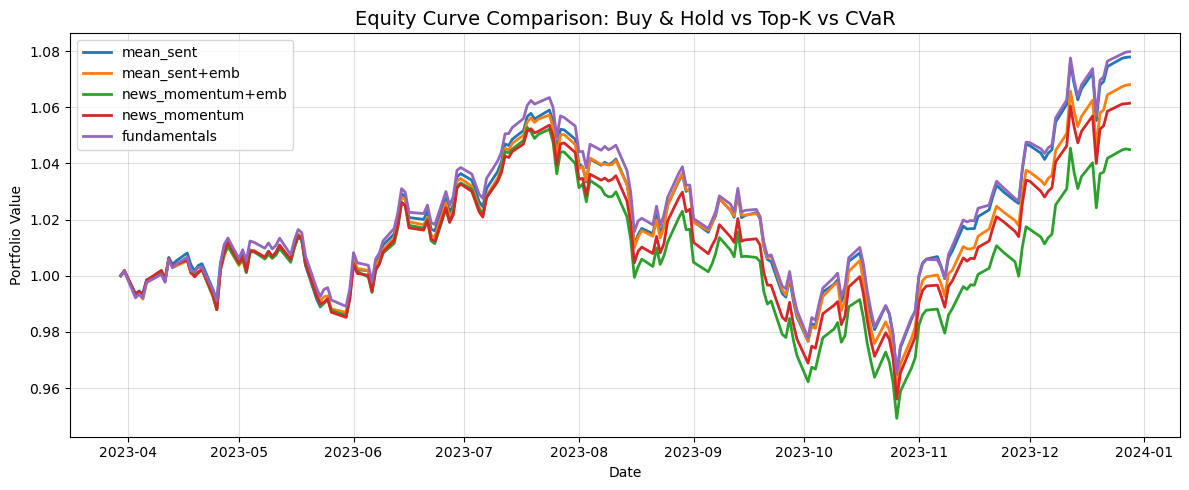


===== CVaR Backtest Completed for All Models =====
mean_sent                  Sharpe=1.142  AnnRet=10.58%
mean_sent+emb              Sharpe=0.989  AnnRet=9.23%
news_momentum+emb          Sharpe=0.654  AnnRet=6.07%
news_momentum              Sharpe=0.895  AnnRet=8.32%
fundamentals               Sharpe=1.166  AnnRet=10.84%


In [37]:
# ================================================================
# CLEAN + PREPARE ALL PREDICTION DATAFRAMES
# ================================================================

models_raw = {
    "mean_sent": preds_lgbm_best_test_DMS_plus_mean_sent.copy(),
    "mean_sent+emb": preds_lgbm_best_test_DMS_plus_mean_sentiment_plus_embeddings.copy(),
    "news_momentum+emb": preds_lgbm_best_test_DMS_plus_news_momentum_plus_embeddings.copy(),
    "news_momentum": preds_lgbm_best_test_DMS_plus_news_momentum.copy(),
    "fundamentals": preds_lgbm_best_val_DMS_plus_funds.copy(),
}

def prepare_preds(df):
    """Clean: keep test period, rename columns, ensure datetime."""
    df = df.copy()

    # keep only test rows (2023)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df[df["Date"] >= "2023-01-01"]

    # rename to expected names by backtester
    if "y_pred" in df.columns:
        df = df.rename(columns={"y_pred": "pred"})
    if "y_true" in df.columns:
        df = df.rename(columns={"y_true": "ret_1d_raw"})

    # drop rows with missing true return
    df = df.dropna(subset=["ret_1d_raw"]).copy()

    return df


# apply cleaning
models_clean = {name: prepare_preds(df) for name, df in models_raw.items()}

# ================================================================
# RUN CVaR BACKTEST FOR EACH MODEL
# ================================================================

results_cvar = {}
pv_cvar_dict = {}
dates_ref = None   # will store the reference date index

for name, df in models_clean.items():
    print(f"\n===== Running CVaR Backtest for {name} =====")

    # build matrices for this model
    pred_mat, ret_mat, dates, tickers = build_prediction_and_return_matrices(df, pred_col="pred")

    if dates_ref is None:
        dates_ref = dates    # fix reference dates for plotting

    # run CVaR strategy
    daily_rets, pv = run_backtest_cvar(
        pred_mat,
        ret_mat,
        window=60,
        alpha=0.95,
        lam=5.0,
        ret_scale=10.0,
        max_weight=0.02,
        turnover_limit=0.10,
        tx_cost=0.0005,
    )

    # compute metrics
    metrics = compute_performance_metrics(
        daily_rets[np.isfinite(daily_rets)],
        pv[np.isfinite(pv)]
    )

    results_cvar[name] = metrics
    pv_cvar_dict[name] = pv

    print(metrics)

# ================================================================
# PLOT ALL CVaR EQUITY CURVES TOGETHER
# ================================================================

plot_comparison_safe(dates_ref, pv_cvar_dict)

print("\n===== CVaR Backtest Completed for All Models =====")
for name, m in results_cvar.items():
    print(f"{name:25s}  Sharpe={m['sharpe']:.3f}  AnnRet={m['ann_return']*100:.2f}%")


In [38]:
import matplotlib.pyplot as plt
import numpy as np

def plot_equity_curves_paper_style(dates, pv_dict, filename=None):
    """
    Plot multiple equity curves with the same visual style
    as the grouped bar chart (paper style).
    """

    plt.style.use("seaborn-v0_8")
    fig, ax = plt.subplots(figsize=(12, 6))

    # --------------------------------------------
    # Professional color palette (consistent)
    # --------------------------------------------
    color_cycle = [
        "#80B1D3",  # blue
        "#FDB462",  # orange
        "#B3DE69",  # green
        "#FB8072",  # red
        "#BC80BD",  # purple
        "#8DD3C7",  # teal
    ]

    colors = {name: color_cycle[i % len(color_cycle)]
              for i, name in enumerate(pv_dict.keys())}

    # --------------------------------------------
    # Ensure all portfolio curves align with dates
    # --------------------------------------------
    T = len(dates)
    for name, pv in pv_dict.items():
        pv = np.array(pv, dtype=float)

        if len(pv) < T:
            pv = np.concatenate([np.full(T - len(pv), np.nan), pv])
        elif len(pv) > T:
            pv = pv[:T]

        pv_dict[name] = pv

    # --------------------------------------------
    # Plot curves
    # --------------------------------------------
    for name, pv in pv_dict.items():
        valid = ~np.isnan(pv)
        ax.plot(
            dates[valid], pv[valid],
            label=name,
            linewidth=2.2,
            color=colors[name],
        )

    # --------------------------------------------
    # Formatting
    # --------------------------------------------
    ax.set_title("Equity Curve Comparison (CVaR Strategies)", fontsize=16, weight="bold")
    ax.set_xlabel("Date", fontsize=13)
    ax.set_ylabel("Portfolio Value", fontsize=13)

    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=12, frameon=True)

    plt.tight_layout()

    # Save to PDF for report
    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()


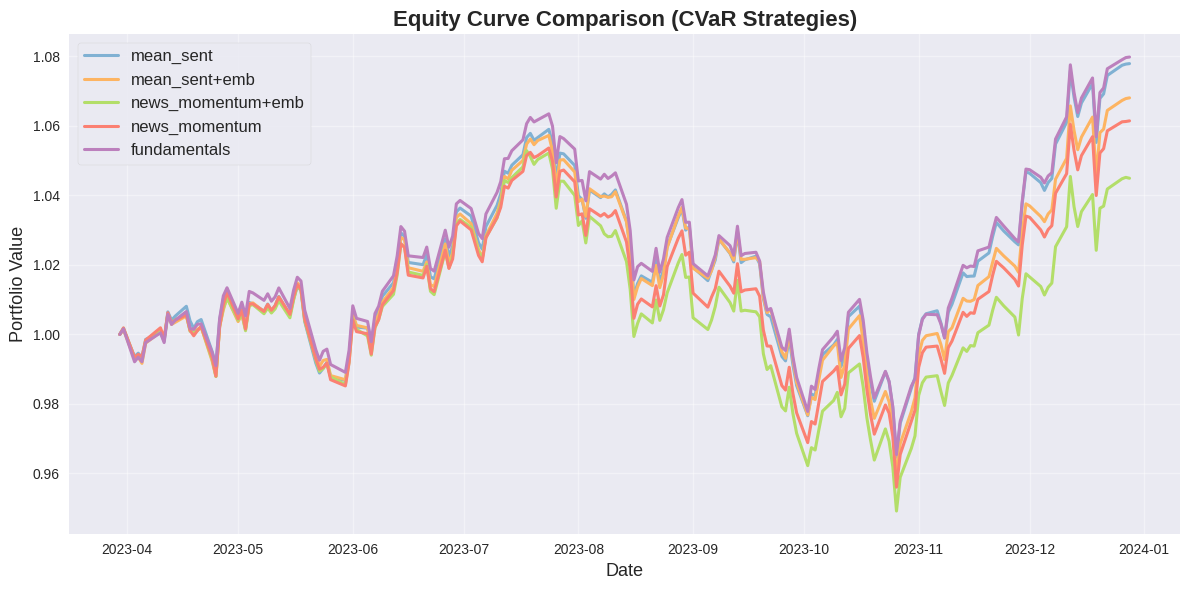

In [39]:
plot_equity_curves_paper_style(
    dates_ref,
    pv_cvar_dict,
    filename="../documents/figures/cvar_equity_curves.pdf"
)


In [32]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

def compute_daily_ic(pred_df):
    """
    pred_df must contain:
      - Date
      - tic
      - pred (prediction)
      - ret_1d_raw (realized next-day return)
    Returns:
      daily IC series, mean IC, IR
    """
    df = pred_df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    # group by date
    ic_list = []

    for date, g in df.groupby("Date"):
        if g["pred"].nunique() == 1:
            continue  # avoid constant predictions
        ic = spearmanr(g["pred"], g["ret_1d_raw"]).correlation
        ic_list.append(ic)

    ic_series = pd.Series(ic_list)

    mean_ic = ic_series.mean()
    std_ic = ic_series.std()
    ir = mean_ic / std_ic if std_ic > 0 else np.nan

    return ic_series, mean_ic, std_ic, ir


In [33]:
ic_results = {}

for name, df in models_clean.items():
    print(f"\n===== Computing IC for {name} =====")
    ic_series, mean_ic, std_ic, ir = compute_daily_ic(df)
    ic_results[name] = {
        "mean_ic": mean_ic,
        "std_ic": std_ic,
        "ir": ir
    }
    print(f"Mean IC: {mean_ic:.6f}")
    print(f"Std IC:  {std_ic:.6f}")
    print(f"IR:      {ir:.6f}")



===== Computing IC for mean_sent =====
Mean IC: 0.026848
Std IC:  0.158781
IR:      0.169087

===== Computing IC for mean_sent+emb =====
Mean IC: 0.020674
Std IC:  0.126904
IR:      0.162909

===== Computing IC for news_momentum+emb =====
Mean IC: 0.014571
Std IC:  0.111087
IR:      0.131170

===== Computing IC for news_momentum =====
Mean IC: 0.027856
Std IC:  0.146128
IR:      0.190624

===== Computing IC for fundamentals =====
Mean IC: 0.028339
Std IC:  0.169809
IR:      0.166886
